In [12]:
import jax
import jax.numpy as jnp
import time
import optax
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import ot
import ot as pot
import torchdyn
from ott.neural.networks import icnn
from ott.neural.methods import neuraldual
from sklearn.datasets import make_blobs, make_swiss_roll
from typing import Any, Callable, Sequence, Tuple
import flax.linen as nn
from jax import jit
from functools import partial
import numpy as np
from collections import namedtuple
import itertools
from scipy.spatial.distance import cdist

Defining the Wasserstein distance :

In [2]:
def wasserstein_distance(point_cloud1, point_cloud2):
    pairwise_distances = cdist(point_cloud1, point_cloud2, metric='euclidean')
    
    total_distance = 0.0
    for i in range(len(point_cloud1)):
        total_distance += np.min(pairwise_distances[i])
        
    return total_distance / len(point_cloud1)

## 1) Generating synthetic data

In [21]:
X_np, _ = make_blobs(n_samples=1000, n_features=2, centers=[[0, 0]], random_state=42)
Y_np, _ = make_blobs(n_samples=1000, n_features=2, centers=[[0, 10], [0, -10]], random_state=43)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)


n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

def infinite_iterator(data):
    while True:
        yield data

DataLoader = namedtuple("DataLoader", ["source_iter", "target_iter"])
train_dtld = DataLoader(source_iter=infinite_iterator(X_train),
                               target_iter=infinite_iterator(Y_train))
valid_dtld = DataLoader(source_iter=infinite_iterator(X_valid),
                               target_iter=infinite_iterator(Y_valid))

X = next(train_dtld.source_iter)
Y = next(train_dtld.target_iter)
X_valid = next(valid_dtld.source_iter)
Y_valid = next(valid_dtld.target_iter)

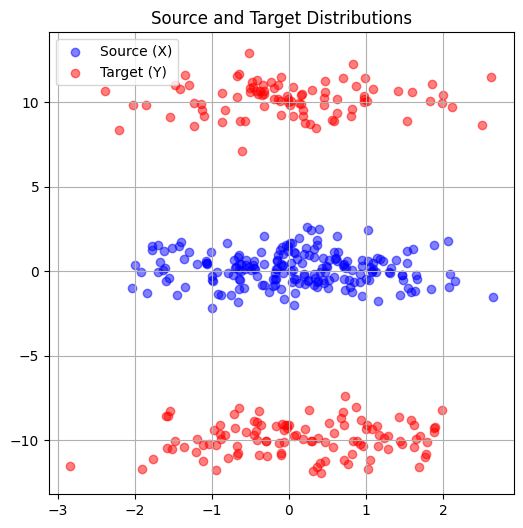

In [4]:
X_np = jnp.array(X).to_py() if hasattr(X, 'to_py') else jnp.array(X)
Y_np = jnp.array(Y).to_py() if hasattr(Y, 'to_py') else jnp.array(Y)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], color='blue', alpha=0.5, label='Source (X)')
plt.scatter(Y_np[:, 0], Y_np[:, 1], color='red', alpha=0.5, label='Target (Y)')
plt.title("Source and Target Distributions")
plt.legend()
plt.grid(True)
plt.show()

## 2) Defining the ICNN 

In [5]:
PRNGKey = Any
Shape = Tuple[int]
Dtype = Any
Array = Any

class PositiveDense(nn.Module):
    dim_hidden: int
    beta: int = 30.0
    kernel_init: Callable[[PRNGKey, Shape, Dtype], Array] = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, inputs):
        x = inputs
        kernel = self.param('kernel', self.kernel_init, (inputs.shape[-1], self.dim_hidden))
        kernel = 1/self.beta * nn.softplus( self.beta * kernel)
        x = jax.lax.dot_general(inputs, kernel, (((inputs.ndim - 1,), (0,)), ((), ())))
        return x
    

class ICNN(nn.Module):
  dim_hidden: Sequence[int]
  act_fn: Callable = nn.elu
  init_fn: Callable = nn.initializers.variance_scaling(scale=1., distribution="normal", mode="fan_avg")

  def setup(self):
    self.dim = self.dim_hidden + (1,)
    self.w_zs = [PositiveDense(feature, kernel_init=self.init_fn) for feature in self.dim]
    self.w_ys = [nn.Dense(feature, use_bias=True, kernel_init=self.init_fn) for feature in self.dim]

  @nn.compact
  def __call__(self, input):
    y = input
    z = jnp.zeros(shape=y.shape)
    for w_z, w_y in zip(self.w_zs[:-1], self.w_ys[:-1]):
      z = self.act_fn(w_z(z) + w_y(y))
    z = self.w_zs[-1](z) + self.w_ys[-1](y)
    return z.squeeze()

## 3) Testing the ICNN on the Gaussian blob data

  0%|          | 0/5000 [00:00<?, ?it/s]

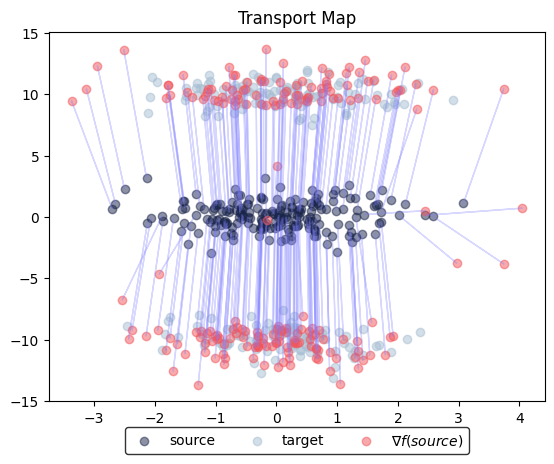

Wasserstein distance between target predictions and data samples: 0.48
Neural dual distance between source and target data: 81.84


In [9]:
optimizer_f = optax.adam(learning_rate=1e-4, b1=0.5, b2=0.9, eps=1e-8)
optimizer_g = optax.adam(learning_rate=1e-4, b1=0.5, b2=0.9, eps=1e-8)

neural_f = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)
neural_g = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)

neural_dual_solver = neuraldual.W2NeuralDual(2, neural_f, neural_g, optimizer_f, optimizer_g, num_train_iters = 5000)
learned_potentials_identity = neural_dual_solver(*train_dtld, *valid_dtld)

learned_potentials_identity.plot_ot_map(X_valid, Y_valid, forward=True)
plt.title("Optimal transport Map")
plt.show()

transported_samples_forward = learned_potentials_identity.transport(X_valid, forward = True)

wasserstein_dist = wasserstein_distance(transported_samples_forward, Y_valid)
print(f"Wasserstein distance: {wasserstein_dist:.2f}")

dual_dist = learned_potentials_identity.distance(X_valid, Y_valid)
print(f"Neural dual distance: {dual_dist:.2f}")

## 4) Testing the ICNN on the Swiss roll data

In [34]:
X_np, _ = make_swiss_roll(n_samples=1000, noise=1.5, random_state=42)
Y_np, _ = make_swiss_roll(n_samples=1000, noise=0, random_state=42)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)


n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

def infinite_iterator(data):
    while True:
        yield data

DataLoader = namedtuple("DataLoader", ["source_iter", "target_iter"])
train_dtld = DataLoader(source_iter=infinite_iterator(X_train),
                               target_iter=infinite_iterator(Y_train))
valid_dtld = DataLoader(source_iter=infinite_iterator(X_valid),
                               target_iter=infinite_iterator(Y_valid))

X = next(train_dtld.source_iter)
Y = next(train_dtld.target_iter)
X_valid = next(valid_dtld.source_iter)
Y_valid = next(valid_dtld.target_iter)

  0%|          | 0/5000 [00:00<?, ?it/s]

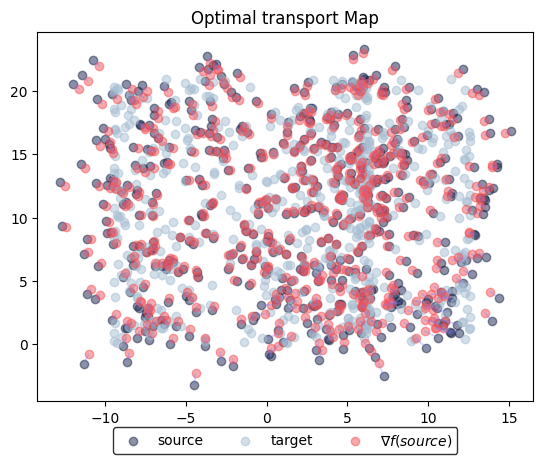

Wasserstein distance: 1.50
Neural dual distance: 0.19


In [35]:
optimizer_f = optax.adam(learning_rate=1e-4, b1=0.5, b2=0.9, eps=1e-8)
optimizer_g = optax.adam(learning_rate=1e-4, b1=0.5, b2=0.9, eps=1e-8)

neural_f = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)
neural_g = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)

neural_dual_solver = neuraldual.W2NeuralDual(3, neural_f, neural_g, optimizer_f, optimizer_g, num_train_iters = 5000)
learned_potentials_identity = neural_dual_solver(*train_dtld, *valid_dtld)

learned_potentials_identity.plot_ot_map(X_valid, Y_valid, forward=True)
plt.title("Optimal transport Map")
plt.show()

transported_samples_forward = learned_potentials_identity.transport(X_valid, forward = True)
wasserstein_dist = wasserstein_distance(transported_samples_forward, Y_valid)
print(f"Wasserstein distance: {wasserstein_dist:.2f}")

dual_dist = learned_potentials_identity.distance(X_valid, Y_valid)
print(f"Neural dual distance: {dual_dist:.2f}")